In [2]:
# Install necessary libraries (uncomment if not already installed)
%pip install pandas scikit-learn matplotlib


[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Implementing DBSCAN Clustering on Stock Features Dataset

In this notebook, we will apply the DBSCAN clustering algorithm on stock features data to identify clusters of similar stocks. 
We'll use various features like Daily Returns, Moving Averages, Volatility, RSI, Volume, High-Low differences, and others.

### Steps:
1. Load the dataset and preprocess it.
2. Implement DBSCAN.
3. Tune parameters to optimize clustering.
4. Visualize and interpret the clusters.


In [3]:
import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import os


# Load the dataset
data = pd.read_csv("summary_statistics_2015_2017.csv")

# Display the first few rows
data.head()


,Ticker,Daily Return_25th,Daily Return_50th,Daily Return_75th,MA-10_25th,MA-10_50th,MA-10_75th,EMA_25th,EMA_50th,EMA_75th,...,High-Low_75th,Close-Open_25th,Close-Open_50th,Close-Open_75th,ROC-10_25th,ROC-10_50th,ROC-10_75th,Log Returns_25th,Log Returns_50th,Log Returns_75th
0,ava,-0.514967,0.091394,0.705574,31.729925,38.358500,40.462350,31.557265,38.294764,40.236010,...,1.963899,-0.444202,0.091965,0.718775,-1.376743,0.492783,2.642881,-0.005163,0.000914,0.007031
1,htrb,-0.120559,-0.074559,0.124475,40.077523,40.078445,40.079367,40.001296,40.008732,40.034258,...,0.062299,0.000000,0.000000,0.024992,0.092266,0.092266,0.092266,-0.001206,-0.000746,0.001244
2,ntnx,-1.987952,-0.178333,1.614238,19.469000,23.060010,28.129000,20.132960,23.280644,28.883276,...,6.464302,-2.394767,-0.166483,1.254175,-7.083371,0.756718,6.785858,-0.020080,-0.001785,0.016013
3,arr,-0.536369,0.058883,0.675856,16.872300,18.287900,20.697550,16.953770,18.151033,20.593031,...,2.040735,-0.498663,0.048341,0.664787,-1.990576,0.679340,3.130509,-0.005378,0.000589,0.006736
4,bmlp,-1.013189,-0.017921,1.299257,47.072645,48.575850,51.251925,47.986196,50.552000,51.509924,...,0.173507,-0.024854,0.000000,0.000000,-4.091178,-2.061405,-0.506906,-0.010184,-0.000179,0.012909


## Step 2: Data Preprocessing

DBSCAN is sensitive to the scale of features. We’ll standardize the features to give each an equal impact on clustering.


In [4]:
# Step 1: Drop rows with missing values and reset index
data_no_na = data.dropna().reset_index(drop=True)

# Step 2: Select only numeric columns for scaling
numeric_cols = data_no_na.select_dtypes(include=[np.number]).columns
data_numeric = data_no_na[numeric_cols]

# Step 3: Scale the numeric data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_numeric)


## Step 3: DBSCAN Clustering

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) groups points that are close together based on a distance measurement. 
The main parameters to tune are `eps` (maximum distance between two points) and `min_samples` (minimum number of points to form a dense region).


In [5]:
# Step 4: Initialize and fit DBSCAN
dbscan = DBSCAN(eps=0.3, min_samples=8)
dbscan.fit(data_scaled)

# Step 5: Add cluster labels to the data_no_na DataFrame
data_no_na['Cluster'] = dbscan.labels_

# Optional: If you want to include the cluster labels back into the original data
data['Cluster'] = np.nan  # Initialize 'Cluster' column with NaNs in the original DataFrame
data.loc[data_no_na.index, 'Cluster'] = data_no_na['Cluster']


## Step 4: Tuning DBSCAN Parameters

Adjusting `eps` and `min_samples` values can significantly impact DBSCAN's clustering performance. We'll try a few values to find the optimal ones.


In [6]:
from sklearn.metrics import silhouette_score

best_eps, best_min_samples, best_silhouette = 0.5, 5, -1

# Range of eps and min_samples to test
eps_values = np.arange(0.1, 1.1, 0.1)
min_samples_values = range(3, 10)

# Loop through values to find best silhouette score
for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(data_scaled)
        if len(set(labels)) > 1:  # Silhouette score requires at least 2 clusters
            score = silhouette_score(data_scaled, labels)
            if score > best_silhouette:
                best_eps, best_min_samples, best_silhouette = eps, min_samples, score

print(f'Best eps: {best_eps}, Best min_samples: {best_min_samples}, Best silhouette score: {best_silhouette}')


KeyboardInterrupt: 

## Step 5: Visualizing the Clusters

We'll visualize the clusters using a 2D scatter plot. 
We'll apply PCA for dimensionality reduction if necessary to get the top two components for visualization.


c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\manifold\_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


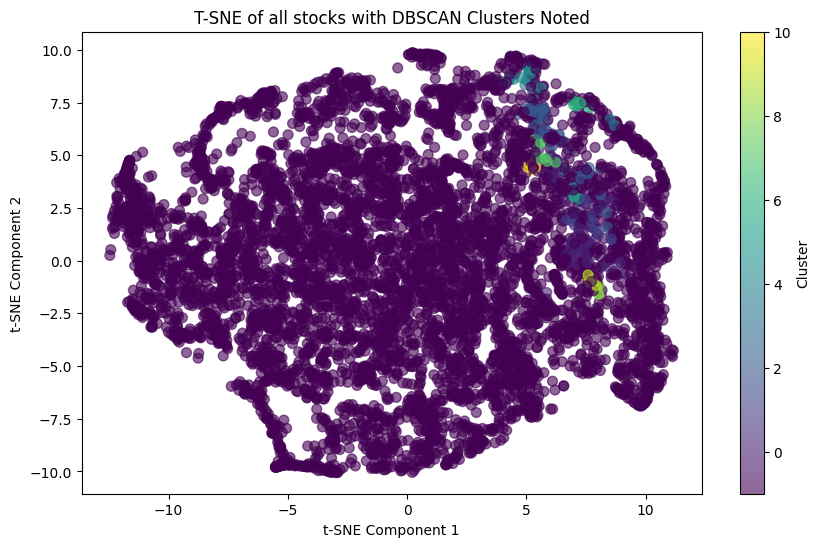

In [7]:
from sklearn.manifold import TSNE
# Step 6: Use t-SNE for visualization
tsne = TSNE(n_components=2, perplexity=30, n_iter=300)
data_reduced = tsne.fit_transform(data_scaled)

# Step 7: Plot clusters with t-SNE
plt.figure(figsize=(10, 6))
plt.scatter(data_reduced[:, 0], data_reduced[:, 1], c=data_no_na['Cluster'], cmap='viridis', s=50, alpha=0.6)
plt.title('T-SNE of all stocks with DBSCAN Clusters Noted')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.colorbar(label='Cluster')
plt.show()

In [8]:
# Assuming `data_no_na` is your DataFrame that contains the 'Ticker' and 'Cluster' columns

# Group by 'Cluster' and list tickers in each cluster
clustered_tickers = data_no_na.groupby('Cluster')['Ticker'].apply(list)

# Display tickers for each cluster
for cluster, tickers in clustered_tickers.items():
    print(f"Cluster {cluster}:")
    print(", ".join(tickers))
    print("\n" + "-"*50 + "\n")


Cluster -1:
ava, ntnx, arr, bmlp, cone, exg, tpvy, orbk, cni, sfun, yesr, vrts, snx, sptm, baba, lxp, rhe_a, upld, bjz, rail, wbir, mlr, hylb, matr, ecf_a, gldw, ns, cid, thg, cubi, cio_a, abc, desc, fbhs, pbr, tell, ctbi, hbcp, hubs, slno, bid, ntz, andv, ggb, lc, macqu, hseb, amma, mnst, ichr, vec, gale, hp, cog, crak, vnla, tcon, psmt, appn, wec, bkt, zgnx, zeal, clns_c-cl, ger, sngx, sce_l, vbfc, smplw, stly, ftxo, nly_e, kop, nee, trxc, nav, neog, qtrh, out, cig-c, shag, kn, acm, gmre, derm, tsla, scyx, gden, glre, apwc, y, eix, rlh, vcra, camp, bidu, apb, kblmr, igi, pcyg, nbix, chmg, nbh, wfbi, pwr, info, lnn, psa, kang, vrs, googl, cxw, fpay, riot, ytra, gam, unh, nwsa, pcmi, isg, ckx, mpac, lrge, weys, tnh, kvhi, cmcm, tatt, mmp, axs_e, mic, juno, pgc, anet, felp, bhf, rlgt_a, rmbl, shak, kb, dit, hsbc, shw, agr, ocsi, qcp, sld, pes, gdp, pffr, pslv, kyn, ivz, hri, smin, ttoo, fdp, ir, nvro, aeb, drua, ma, bhacr, xrx, gsl, hurn, boch, pro, incr, exk, iaf, ecom, bybk, schk, aci

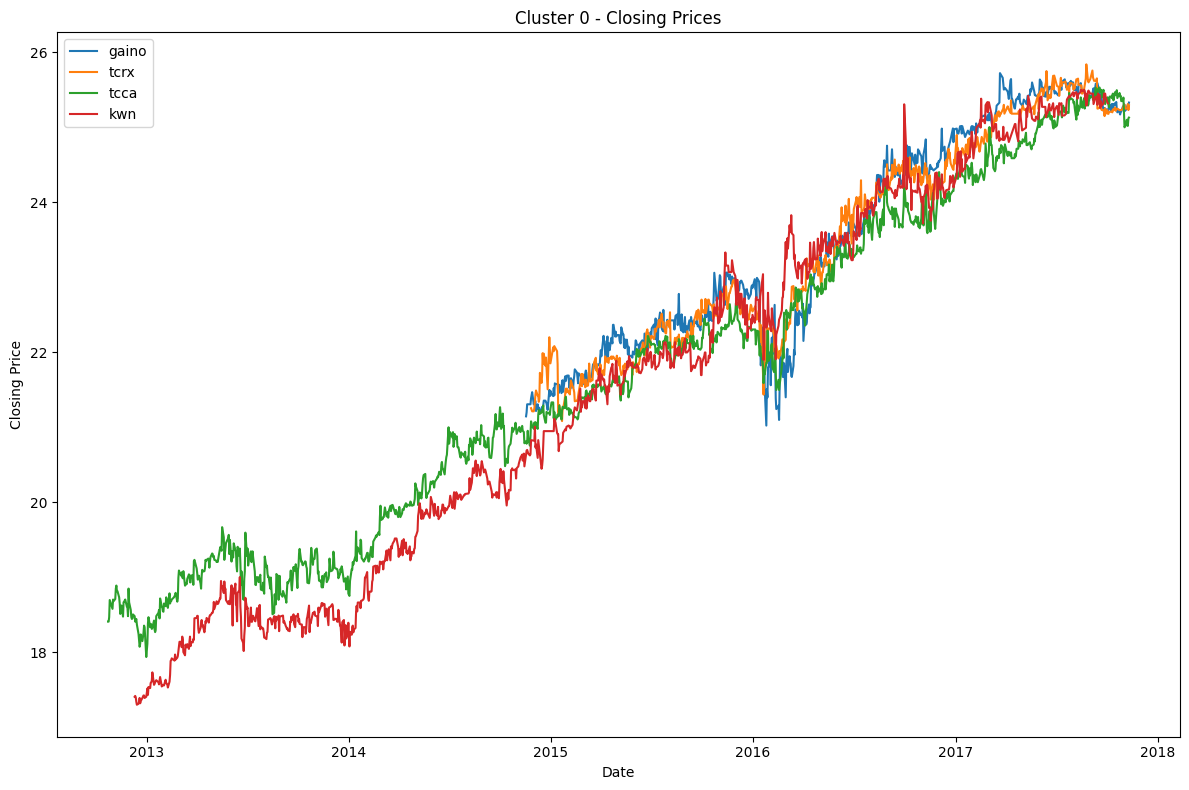

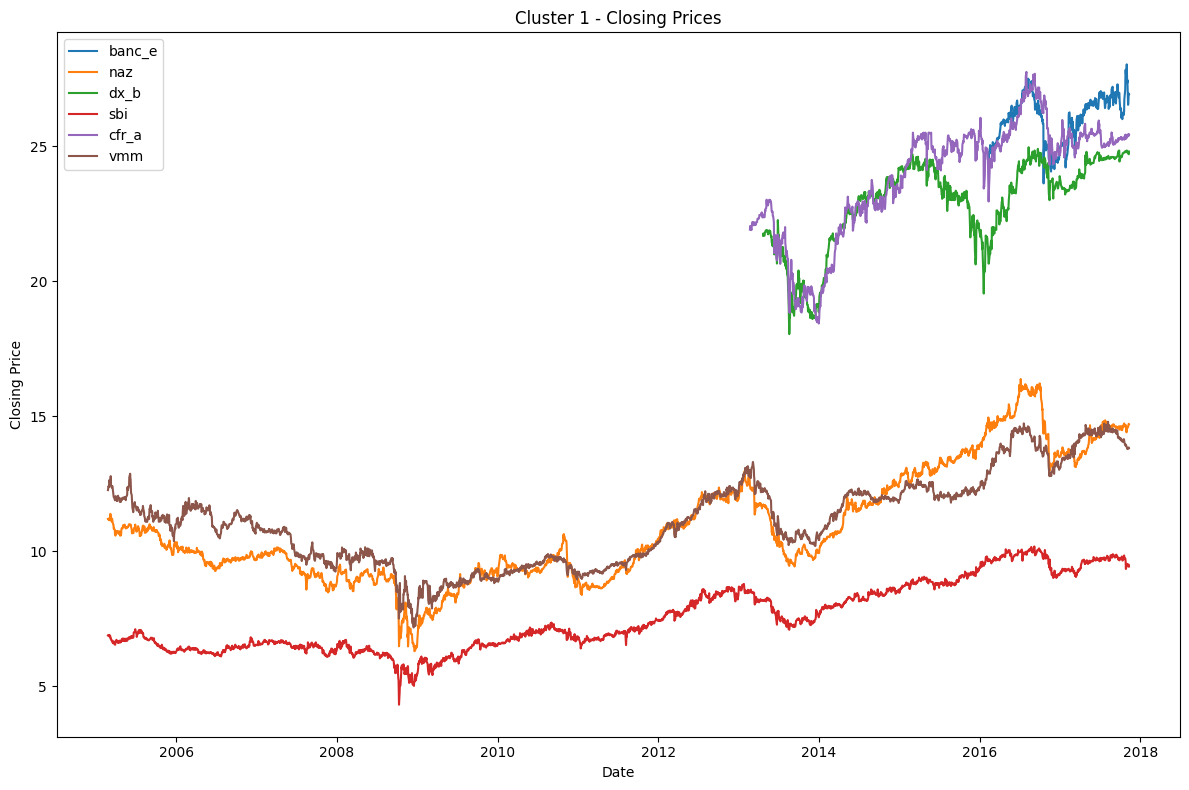

In [12]:
# Define the path to the dataset folder
data_folder = 'dataset/stock_csv'

# Define your clusters (replace this with your actual cluster data)
clusters = {
    0: ['gaino', 'tcrx', 'tcca', 'kwn'],  # Cluster 0 example
    1: ['banc_e', 'naz', 'dx_b', 'sbi', 'cfr_a', 'vmm'],   # Cluster 1 example
    # Add more clusters as needed
}

# Function to load and plot data for each cluster
def plot_clusters(clusters, data_folder):
    for cluster_id, tickers in clusters.items():
        plt.figure(figsize=(12, 8))
        plt.title(f'Cluster {cluster_id} - Closing Prices')
        plt.xlabel('Date')
        plt.ylabel('Closing Price')

        # Loop through each ticker in the cluster
        for ticker in tickers:
            file_path = os.path.join(data_folder, f'{ticker}.us.csv')
            if os.path.exists(file_path):
                # Load the data for each stock
                stock_data = pd.read_csv(file_path, parse_dates=['Date'], index_col='Date')
                
                # Plot the closing price time series
                plt.plot(stock_data.index, stock_data['Close'], label=ticker)
            else:
                print(f"File for {ticker} not found at {file_path}")

        plt.legend()
        plt.tight_layout()
        plt.show()

# Call the function to plot clusters
plot_clusters(clusters, data_folder)